In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_csv_path = "results.csv"
results_df = pd.read_csv(results_csv_path)

headers = results_df.columns.tolist()
num_boulders = len([h for h in headers if h.startswith("Boulder")])

boulder_total_tops = np.zeros(num_boulders, dtype=int)
boulder_total_zones = np.zeros(num_boulders, dtype=int)
boulder_total_top_attempts = np.zeros(num_boulders, dtype=int)
boulder_total_zone_attempts = np.zeros(num_boulders, dtype=int)
num_competitors = len(results_df)

for idx, row in results_df.iterrows():
	for i in range(num_boulders):
		boulder_result = row[f"Boulder {i+1}"]
		if pd.isna(boulder_result):
			continue

		# boulder_result is expected to be in the format "B{boulder_number} T{top}Z{zone}", e.g. "B2 T1Z2"

		parts = boulder_result.split(" ")
		if len(parts) != 2:
			continue

		attempt_data_part = parts[1]

		# First part is the boulder number, second part contains top and zone information
		top_part, zone_part = attempt_data_part[:2], attempt_data_part[2:]
		top_attempts = int(top_part[1:])
		zone_attempts = int(zone_part[1:])

		top_score = 1 if top_attempts > 0 else 0
		zone_score = 1 if zone_attempts > 0 else 0

		boulder_total_tops[i] += top_score
		boulder_total_zones[i] += zone_score
		boulder_total_top_attempts[i] += top_attempts
		boulder_total_zone_attempts[i] += zone_attempts

boulder_indices = np.arange(0, num_boulders)

# Sort boulders by total tops, then total zones, then total top attempts, then total zone attempts
boulder_indices_sorted_by_difficulty = np.lexsort((
	boulder_total_zone_attempts,
	boulder_total_top_attempts,
	-boulder_total_zones,
	-boulder_total_tops
))

In [28]:
boulder_top_rates = boulder_total_tops / num_competitors
boulder_zone_rates = boulder_total_zones / num_competitors
boulder_avg_top_attempts = boulder_total_top_attempts / boulder_total_tops
boulder_avg_zone_attempts = boulder_total_zone_attempts / boulder_total_zones

for idx in boulder_indices_sorted_by_difficulty:
	print(f"Boulder {idx+1}: Top Rate: {boulder_top_rates[idx]:.2%}, Zone Rate: {boulder_zone_rates[idx]:.2%}, Avg Top Attempts: {boulder_avg_top_attempts[idx]:.2f}, Avg Zone Attempts: {boulder_avg_zone_attempts[idx]:.2f}")

Boulder 16: Top Rate: 96.40%, Zone Rate: 98.20%, Avg Top Attempts: 1.08, Avg Zone Attempts: 1.06
Boulder 14: Top Rate: 96.40%, Zone Rate: 97.30%, Avg Top Attempts: 1.28, Avg Zone Attempts: 1.28
Boulder 8: Top Rate: 93.69%, Zone Rate: 98.20%, Avg Top Attempts: 1.02, Avg Zone Attempts: 1.00
Boulder 20: Top Rate: 91.89%, Zone Rate: 94.59%, Avg Top Attempts: 1.13, Avg Zone Attempts: 1.19
Boulder 19: Top Rate: 74.77%, Zone Rate: 76.58%, Avg Top Attempts: 1.66, Avg Zone Attempts: 1.46
Boulder 4: Top Rate: 59.46%, Zone Rate: 73.87%, Avg Top Attempts: 1.83, Avg Zone Attempts: 1.26
Boulder 2: Top Rate: 54.05%, Zone Rate: 62.16%, Avg Top Attempts: 2.32, Avg Zone Attempts: 2.17
Boulder 12: Top Rate: 51.35%, Zone Rate: 61.26%, Avg Top Attempts: 2.42, Avg Zone Attempts: 2.12
Boulder 1: Top Rate: 36.94%, Zone Rate: 59.46%, Avg Top Attempts: 2.29, Avg Zone Attempts: 1.82
Boulder 6: Top Rate: 36.04%, Zone Rate: 58.56%, Avg Top Attempts: 1.77, Avg Zone Attempts: 1.71
Boulder 10: Top Rate: 34.23%, Zone 

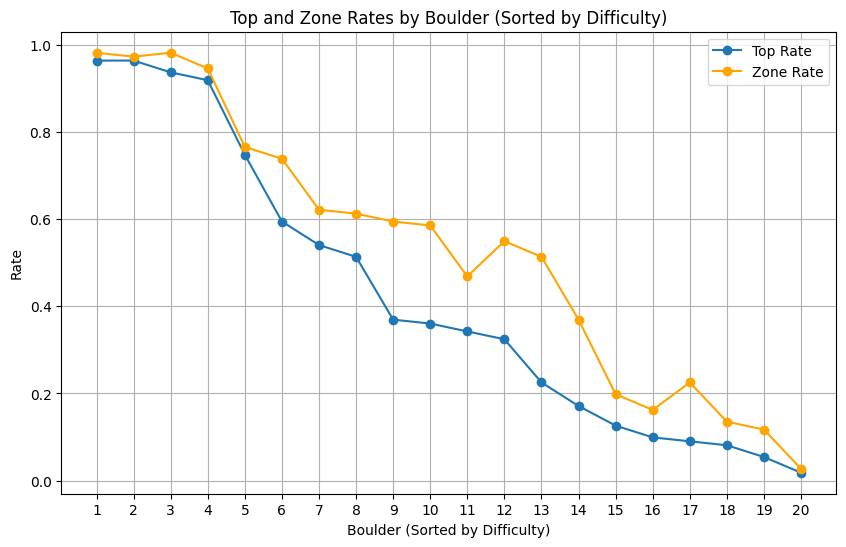

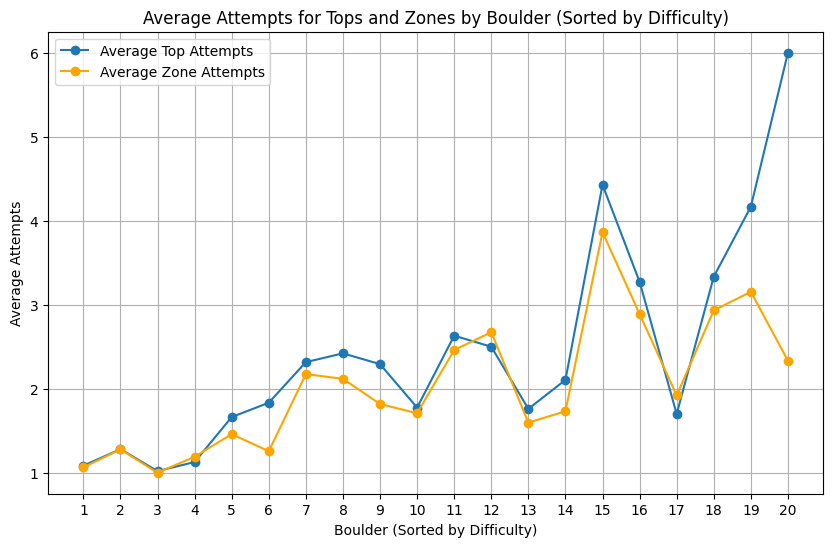

In [ ]:
# First plot, sorted top rate by difficulty
boulder_top_rates_sorted = boulder_total_tops[boulder_indices_sorted_by_difficulty] / num_competitors
boulder_zone_rates_sorted = boulder_total_zones[boulder_indices_sorted_by_difficulty] / num_competitors
plt.figure(figsize=(10, 6))
plt.plot(boulder_indices + 1, boulder_top_rates_sorted, marker="o")
plt.plot(boulder_indices + 1, boulder_zone_rates_sorted, marker="o", color="orange")
plt.title("Top and Zone Rates by Boulder (Sorted by Difficulty)")
plt.xlabel("Boulder (Sorted by Difficulty)")
plt.ylabel("Rate")
plt.legend(["Top Rate", "Zone Rate"])
plt.xticks(boulder_indices_sorted_by_difficulty + 1)
plt.grid()
plt.show()

# Second plot, average attempts for tops and zones by difficulty
boulder_avg_top_attempts_sorted = boulder_total_top_attempts[boulder_indices_sorted_by_difficulty] / boulder_total_tops[boulder_indices_sorted_by_difficulty]
boulder_avg_zone_attempts_sorted = boulder_total_zone_attempts[boulder_indices_sorted_by_difficulty] / boulder_total_zones[boulder_indices_sorted_by_difficulty]
plt.figure(figsize=(10, 6))
plt.plot(boulder_indices + 1, boulder_avg_top_attempts_sorted, marker="o")
plt.plot(boulder_indices + 1, boulder_avg_zone_attempts_sorted, marker="o", color="orange")
plt.title("Average Attempts for Tops and Zones by Boulder (Sorted by Difficulty)")
plt.xlabel("Boulder (Sorted by Difficulty)")
plt.ylabel("Average Attempts")
plt.legend(["Average Top Attempts", "Average Zone Attempts"])
plt.xticks(boulder_indices_sorted_by_difficulty + 1)
plt.grid()
plt.show()